# 3. Visualize (no download)

With the `viz` extra (`pip install "euroflood[viz]"`), a FloodFrame renders straight from the
index — no raster download. Static plots use **matplotlib**; interactive maps use **folium**.
This tutorial tours the two main views (recurrence and footprints) and the options that make
them presentation-ready.

From here on we query with `shape="bbox"` (introduced in tutorial 02) — a clean rectangular ROI,
so the maps aren't clipped by Zutphen's jagged boundary that follows the IJssel.

In [1]:
import euroflood as ef

cat = ef.floods("Zutphen, Netherlands", shape="bbox")

## Flood-recurrence heatmap

A bare `.plot()` shows how often each ~90 m pixel flooded (darker = more recorded floods),
derived from the index alone:

<Axes: title={'center': 'Flood recurrence (recorded floods per pixel)'}>

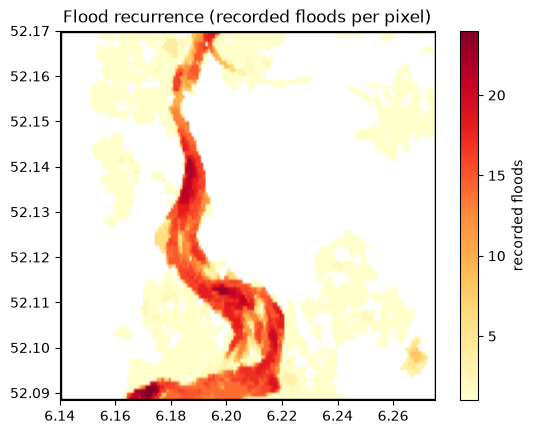

In [2]:
cat.plot()

It accepts matplotlib-style options — a different colormap, a fixed `vmax`, and whether to
draw the query outline:

<Axes: title={'center': 'Flood recurrence (recorded floods per pixel)'}>

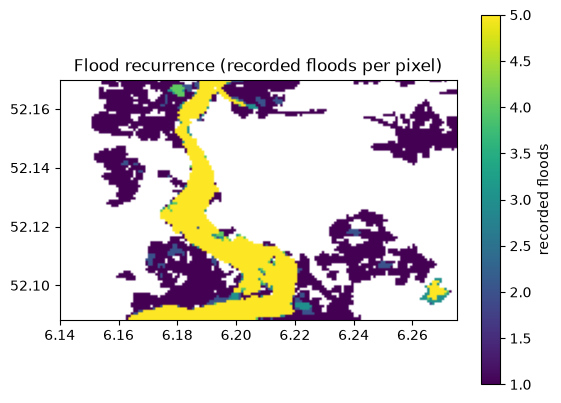

In [3]:
cat.plot(cmap="viridis", vmax=5, boundary=False)

Pass `event_id=` to see a **single event's** footprint instead of the recurrence count:

<Axes: title={'center': 'Flood footprint — event 4049036842'}>

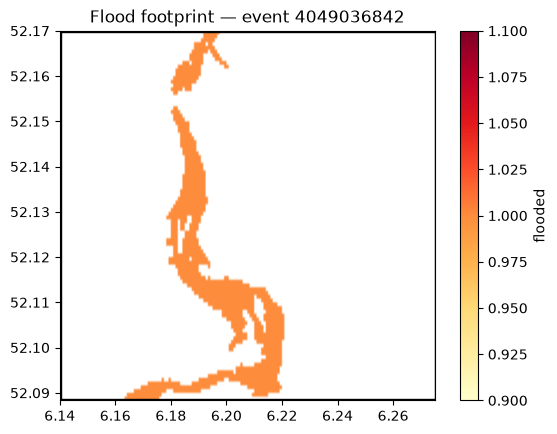

In [4]:
one = int(cat.iloc[0]["event_id"])
cat.plot(event_id=one)

> Add a **basemap** under any static plot with `basemap=True` (needs network for the tiles):
> `cat.plot(basemap=True, tiles="grayscale")` — presets are `grayscale`, `dark`, `osm`.

## Per-event footprints

`.footprints()` returns a GeoDataFrame with one row per event, its `extent_km2`, and (when
available) `duration_days` — useful as data:

In [5]:
foot = cat.footprints()
foot[["event_id", "date", "extent_km2", "duration_days"]].head()

,event_id,date,extent_km2,duration_days
0,3732793625,2015-01-12,1.042,42
1,1127339359,2015-03-09,0.492,42
2,436160978,2015-12-28,8.025,56
3,1434935811,2016-01-11,0.201,7
4,2231395711,2016-02-08,4.939,42


The same footprints as a static map, coloured by year:

<Axes: title={'center': 'Flood extents by event'}>

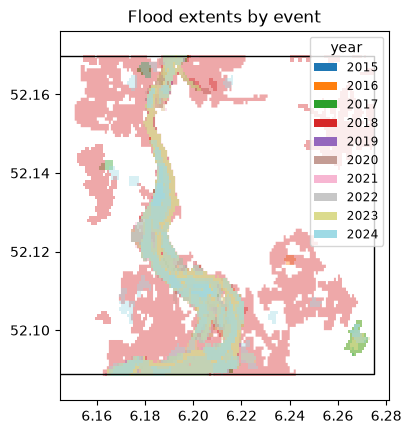

In [6]:
cat.plot(footprints=True)

## Interactive maps

`.explore()` returns a folium map. The default **recurrence** view carries hover tooltips
(how many floods, when) and a click popup listing the dates. Pass `tiles=` for a different
basemap — `"grayscale"`, `"dark"`, or `"osm"`:

In [7]:
cat.explore(tiles="grayscale")

`cat.explore(footprints=True, tiles="grayscale")` instead puts each event on its own
**toggleable layer**, foldered by year — the interactive twin of the static footprints above.